<a href="https://colab.research.google.com/github/Sonali73724/Python/blob/main/week3_SonaliSingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Documantation
I analyzed a country socio-economic dataset, performed exploratory data analysis, applied K-Means and DBSCAN for country segmentation, trained Random Forest and XGBoost models for classification, and extracted insights regarding the key factors influencing country development.

In [1]:
from google.colab import files
uploaded=files.upload()

Saving Country-data.csv to Country-data.csv


In [5]:
import pandas as pd
df=pd.read_csv("Country-data.csv")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [8]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


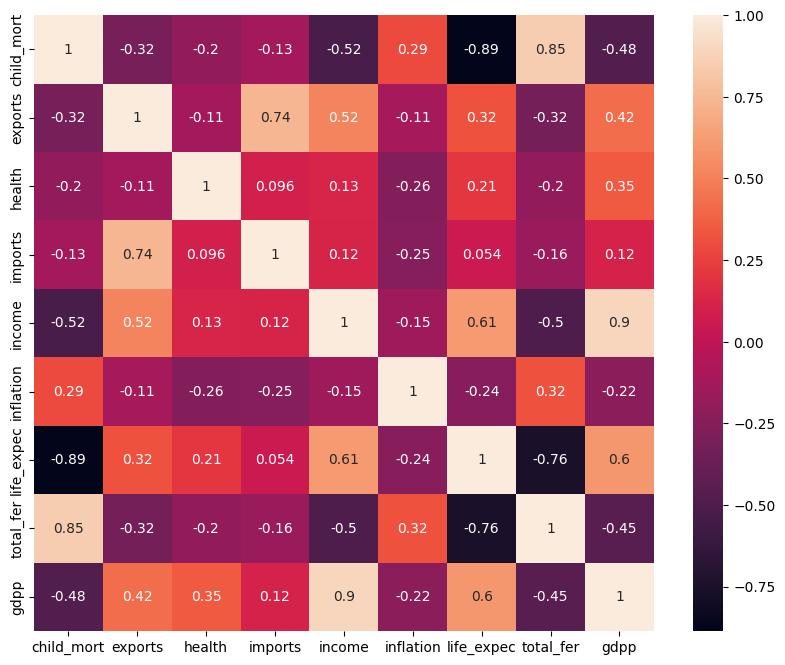

In [9]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("country",axis=1).corr(),annot=True)
plt.show()

# Correlation Analysis
Correlation analysis revealed a strong positive relationship between income and GDP per capita (0.90), while child mortality showed a strong negative correlation with life expectancy (-0.89). These relationships indicate that economically developed countries tend to have higher life expectancy and lower child mortality rates

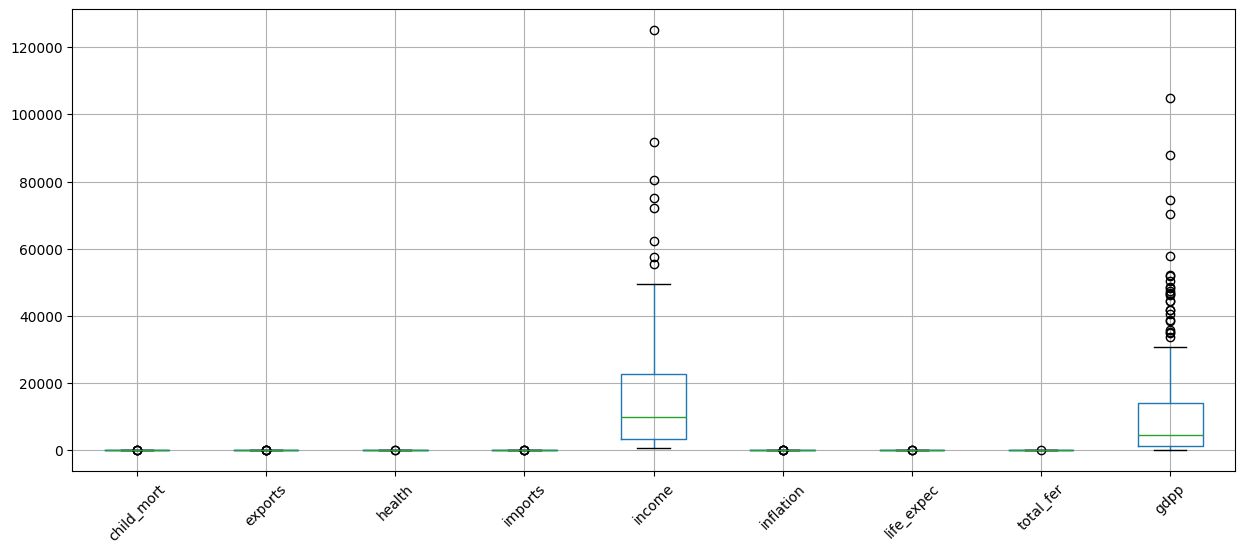

In [11]:
#Outlier Anlysis
plt.figure(figsize=(15,6))
df.drop("country",axis=1).boxplot()
plt.xticks(rotation=45)
plt.show()

#Outlier Anlysuis
Boxplots were used to identify potential outliers in the dataset. Several economic indicators such as income and GDP per capita showed extreme values, which is expected due to the presence of both highly developed and underdeveloped countries.

In [12]:
#Scaling
from sklearn.preprocessing import StandardScaler
X=df.drop("country",axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

#Feature Scaling

Standardization was applied to bring all features onto a common scale before clustering. This prevents variables with larger numerical ranges from dominating the clustering process.

In [13]:
#Elbow Method
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i,random_state=42)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

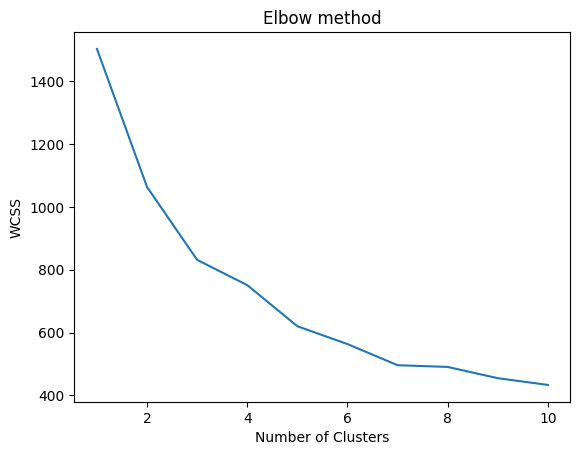

In [14]:
plt.plot(range(1,11),wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

In [15]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3,random_state=42)
df["Cluster"]=km.fit_predict(X_scaled)

In [16]:
df["Cluster"].value_counts()

,count
Cluster,
0,86
2,45
1,36


In [17]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [18]:
#Silhoutte score
from sklearn.metrics import silhouette_score
s=silhouette_score(X_scaled,df["Cluster"])
print("Silhoutte Score:",s)

Silhoutte Score: 0.285600988953231


# K-Means Clustering

The Elbow Method suggested that three clusters were appropriate for the dataset. K-Means clustering was applied with K=3 to segment countries into distinct groups based on socio-economic indicators.

# K-Means Clustering Results

K-Means clustering was performed with K=3 based on the Elbow Method. The countries were segmented into three clusters containing 86, 36, and 45 countries respectively.

The Silhouette Score obtained was 0.286, indicating a moderate level of cluster separation and cohesion. The clustering successfully identified groups of countries with similar socio-economic characteristics.

#interpretation
> 0.5  = Good
0.25-0.5 = Acceptable
< 0.25 = Weak



In [19]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


# Cluster Interpretation

Cluster 1 represents developed countries with high income, high GDP per capita, high life expectancy, and low child mortality.

Cluster 0 represents developing countries with moderate socio-economic indicators.

Cluster 2 represents underdeveloped countries characterized by low income, low GDP per capita, low life expectancy, and high child mortality.

In [20]:
#DBScan
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.5,min_samples=5)
df["DBSCAN_Cluster"]=dbscan.fit_predict(X_scaled)

In [21]:
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


# DBSCAN Clustering

DBSCAN identified one major cluster containing 137 countries and labeled 30 countries as noise/outliers. These outliers represent countries with socio-economic characteristics significantly different from the majority of the dataset.

In [22]:
#Feature
y=df['Cluster']
X=df.drop(['country','Cluster','DBSCAN_Cluster'],axis=1)

In [24]:
#Train-Test Splt
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    random_state=42
)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [26]:
#Prediction
pred_rf=rf.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
acc_rf=accuracy_score(y_test,pred_rf)
print("Accuracy:",acc_rf)

Accuracy: 1.0


# Random Forest Classification

The Random Forest classifier achieved an accuracy of 100% on the test dataset. The model successfully learned the patterns associated with the cluster labels generated through K-Means clustering and demonstrated excellent predictive performance.

In [28]:
#XGBoost
!pip install xgboost

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb=XGBClassifier(
    random_state=42
)
xgb.fit(X_train,y_train)
pred_xgb=xgb.predict(X_test)
acc_xgb=accuracy_score(y_test,pred_xgb)
print("Accuracy:",acc_xgb)

Accuracy: 1.0


# XGBoost Classification

The XGBoost classifier was trained on the clustered dataset and achieved an accuracy of 100% on the test set. The model successfully captured the underlying patterns in the socio-economic indicators and accurately predicted cluster membership.

The performance of XGBoost was comparable to Random Forest, demonstrating the effectiveness of ensemble learning techniques for classification tasks.

# Model Comparison

| Model | Accuracy |
|--------|----------|
| Random Forest | 100% |
| XGBoost | 100% |

Both ensemble learning models achieved perfect classification performance on the clustered dataset. This indicates that the generated clusters were highly separable based on the selected socio-economic indicators.

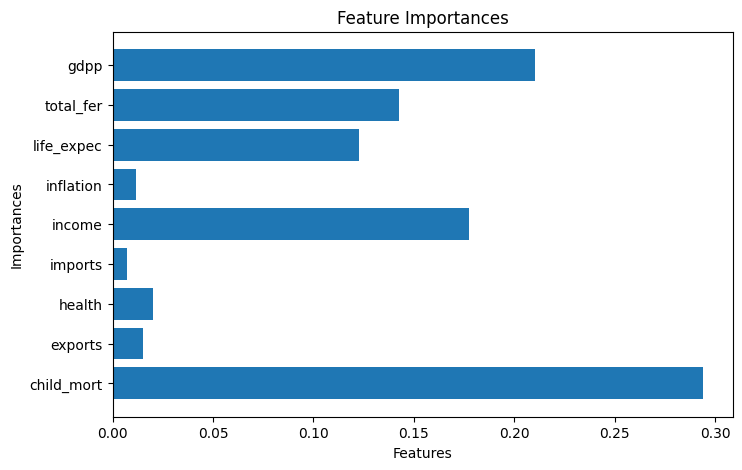

In [30]:
importancs=rf.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(X.columns,importancs)
plt.xlabel("Features")
plt.ylabel("Importances")
plt.title("Feature Importances")
plt.show()

# Feature Importance Analysis

Feature importance analysis revealed that child mortality was the most influential factor in determining country clusters, followed by GDP per capita and income.
Life expectancy and fertility rate also contributed significantly to the classification process.
Economic and health-related indicators were found to be the primary drivers of country segmentation.

# Conclusion

An end-to-end Customer Intelligence System was developed using exploratory data analysis, clustering, and classification techniques.

1.K-Means clustering segmented
countries into three meaningful groups representing developed, developing, and underdeveloped nations. DBSCAN further identified outlier countries with unique socio-economic characteristics.

2.Random Forest classification achieved 100% accuracy in predicting cluster membership, demonstrating strong predictive capability. Feature importance analysis highlighted child mortality, GDP per capita, and income as the most significant factors influencing country segmentation.

3.The project successfully generated actionable insights that can support policy planning, resource allocation, and socio-economic assessment.